## Angel CBDI3 Project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import openpyxl
from scipy import stats
import pingouin as pg

In [2]:
df = pd.read_excel('data/CBDI3 All Evals for NSS.xlsx')
pd.set_option('display.max_columns', None)
df.head(5)

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,Adaptive RDI,Adaptive Z-Score,Adaptive T-Score,Adaptive NCE,Social-Emotional Sum of Scaled Scores,Social-Emotional Developmental Quotient,Social-Emotional Percentile Rank,Social-Emotional 95% Confidence Interval,Social-Emotional RDI,Social-Emotional Z-Score,Social-Emotional T-Score,Social-Emotional NCE,Communication Sum of Scaled Scores,Communication Developmental Quotient,Communication Percentile Rank,Communication 95% Confidence Interval,Communication RDI,Communication Z-Score,Communication T-Score,Communication NCE,Motor Sum of Scaled Scores,Motor Developmental Quotient,Motor Percentile Rank,Motor 95% Confidence Interval,Motor RDI,Motor Z-Score,Motor T-Score,Motor NCE,Cognitive Sum of Scaled Scores,Cognitive Developmental Quotient,Cognitive Percentile Rank,Cognitive 95% Confidence Interval,Cognitive RDI,Cognitive Z-Score,Cognitive T-Score,Cognitive NCE,BDI-3 Total Sum of Scaled Scores,BDI-3 Total Developmental Quotient,BDI-3 Total Percentile Rank,BDI-3 Total 90% Confidence Interval,BDI-3 Total 95% Confidence Interval,BDI-3 Total Z-Score,BDI-3 Total T-Score,BDI-3 Total NCE,Adaptive-Self Care Examiner,Adaptive-Self Care Date of Testing,Adaptive-Self Care RS,Adaptive-Self Care SS,Adaptive-Self Care PR,Adaptive-Self Care AE,Adaptive-Self Care RDI,Adaptive-Self Care CSS,Adaptive-Self Care CSS 90%,Adaptive-Self Care Z-Score,Adaptive-Self Care T-Score,Adaptive-Self Care NCE,Adaptive-Personal Responsibility Examiner,Adaptive-Personal Responsibility Date of Testing,Adaptive-Personal Responsibility RS,Adaptive-Personal Responsibility SS,Adaptive-Personal Responsibility PR,Adaptive-Personal Responsibility AE,Adaptive-Personal Responsibility RDI,Adaptive-Personal Responsibility CSS,Adaptive-Personal Responsibility CSS 90%,Adaptive-Personal Responsibility Z-Score,Adaptive-Personal Responsibility T-Score,Adaptive-Personal Responsibility NCE,Social Emotional-Adult Interaction Examiner,Social Emotional-Adult Interaction Date of Testing,Social Emotional-Adult Interaction RS,Social Emotional-Adult Interaction SS,Social Emotional-Adult Interaction PR,Social Emotional-Adult Interaction AE,Social Emotional-Adult Interaction RDI,Social Emotional-Adult Interaction CSS,Social Emotional-Adult Interaction CSS 90%,Social Emotional-Adult Interaction Z-Score,Social Emotional-Adult Interaction T-Score,Social Emotional-Adult Interaction NCE,Social Emotional-Peer Interaction Examiner,Social Emotional-Peer Interaction Date of Testing,Social Emotional-Peer Interaction RS,Social Emotional-Peer Interaction SS,Social Emotional-Peer Interaction PR,Social Emotional-Peer Interaction AE,Social Emotional-Peer Interaction RDI,Social Emotional-Peer Interaction CSS,Social Emotional-Peer Interaction CSS 90%,Social Emotional-Peer Interaction Z-Score,Social Emotional-Peer Interaction T-Score,Social Emotional-Peer Interaction NCE,Social Emotional-Self Concept / Social Role Examiner,Social Emotional-Self Concept / Social Role Date of Testing,Social Emotional-Self Concept / Social Role RS,Social Emotional-Self Concept / Social Role SS,Social Emotional-Self Concept / Social Role PR,Social Emotional-Self Concept / Social Role AE,Social Emotional-Self Concept / Social Role RDI,Social Emotional-Self Concept / Social Role CSS,Social Emotional-Self Concept / Social Role CSS 90%,Social Emotional-Self Concept / Social Role Z-Score,Social Emotional-Self Concept / Social Role T-Score,Social Emotional-Self Concept / Social Role NCE,Communication-Receptive Communication Examiner,Communication-Receptive Communication Date of Testing,Communication-Receptive Communication RS,Communication-Receptive Communication SS,Communication-Receptive Communication PR,Communication-Receptive Communication AE,Communication-Receptive Communication RDI,Communication-Receptive Communication CSS,Communicat

In [3]:
count = df['Child ID'].value_counts()
repeated = count[count > 1]
print("# of repeated Child ID:", len(repeated))

# of repeated Child ID: 4745


In [4]:
exac_duplicates = df.duplicated().sum()
print('100% repeated rows : ', exac_duplicates)

100% repeated rows :  2281


In [5]:
df_not_duplicated = df.drop_duplicates()
print("# of not duplicated rows: ", len(df_not_duplicated))

# of not duplicated rows:  21666


In [6]:
new_count = df_not_duplicated['Child ID'].value_counts()
other_repeated = new_count[new_count > 1]
print("number of Child ID still repeating(legit evaluations):", len(other_repeated))

number of Child ID still repeating(legit evaluations): 2556


In [7]:
columns_rdi = []

for col in df.columns:
    if 'RDI' in col:
        columns_rdi.append(col)

print("columns with RDI:", len(columns_rdi))
print(columns_rdi)

columns with RDI: 18
['Adaptive RDI', 'Social-Emotional RDI', 'Communication RDI', 'Motor RDI', 'Cognitive RDI', 'Adaptive-Self Care RDI', 'Adaptive-Personal Responsibility RDI', 'Social Emotional-Adult Interaction RDI', 'Social Emotional-Peer Interaction RDI', 'Social Emotional-Self Concept / Social Role RDI', 'Communication-Receptive Communication RDI', 'Communication-Expressive Communication RDI', 'Motor-Gross Motor RDI', 'Motor-Fine Motor RDI', 'Motor-Perceptual Motor RDI', 'Cognitive-Attention and Memory RDI', 'Cognitive-Reasoning / Academic Skills RDI', 'Cognitive-Perception and Concepts RDI']


In [8]:
search = ['Jan-90','Feb-90','Mar-90','Apr-90','May-90','Jun-90',
          'Jul-90','Aug-90','Sep-90','Oct-90','Nov-90','Dec-90']
replace = ['1/90','2/90','3/90','4/90','5/90','6/90','7/90','8/90',
           '9/90','10/90','11/90','12/90']
columns_rdi = ['Adaptive RDI', 'Social-Emotional RDI', 'Communication RDI', 'Motor RDI', 'Cognitive RDI',
                     'Adaptive-Self Care RDI', 'Adaptive-Personal Responsibility RDI', 'Social Emotional-Adult Interaction RDI',
                     'Social Emotional-Peer Interaction RDI', 'Social Emotional-Self Concept / Social Role RDI',
                     'Communication-Receptive Communication RDI', 'Communication-Expressive Communication RDI',
                     'Motor-Gross Motor RDI', 'Motor-Fine Motor RDI', 'Motor-Perceptual Motor RDI',
                     'Cognitive-Attention and Memory RDI', 'Cognitive-Reasoning / Academic Skills RDI',
                     'Cognitive-Perception and Concepts RDI']
for column in columns_rdi:
    for i in range(len(search)):
        looked_value = search[i]
        new_value = replace[i]
        df[column] = df[column].replace(looked_value, str(new_value))

In [9]:
search = ['1990-01-01 00:00:00','1990-02-01 00:00:00','1990-03-01 00:00:00','1990-04-01 00:00:00','1990-05-01 00:00:00',
          '1990-06-01 00:00:00','1990-07-01 00:00:00','1990-08-01 00:00:00','1990-09-01 00:00:00','1990-10-01 00:00:00',
          '1990-11-01 00:00:00','1990-12-01 00:00:00']
replace = ['1/90','2/90','3/90','4/90','5/90','6/90','7/90','8/90',
           '9/90','10/90','11/90','12/90']
columns_rdi = ['Adaptive RDI', 'Social-Emotional RDI', 'Communication RDI', 'Motor RDI', 'Cognitive RDI',
                     'Adaptive-Self Care RDI', 'Adaptive-Personal Responsibility RDI', 'Social Emotional-Adult Interaction RDI',
                     'Social Emotional-Peer Interaction RDI', 'Social Emotional-Self Concept / Social Role RDI',
                     'Communication-Receptive Communication RDI', 'Communication-Expressive Communication RDI',
                     'Motor-Gross Motor RDI', 'Motor-Fine Motor RDI', 'Motor-Perceptual Motor RDI',
                     'Cognitive-Attention and Memory RDI', 'Cognitive-Reasoning / Academic Skills RDI',
                     'Cognitive-Perception and Concepts RDI']
for column in columns_rdi:
    for i in range(len(search)):
        looked_value = search[i]
        new_value = replace[i]
        df[column] = df[column].replace(looked_value, str(new_value))

In [10]:
pd.set_option('display.max_columns', None)
df.head(5)

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,Adaptive RDI,Adaptive Z-Score,Adaptive T-Score,Adaptive NCE,Social-Emotional Sum of Scaled Scores,Social-Emotional Developmental Quotient,Social-Emotional Percentile Rank,Social-Emotional 95% Confidence Interval,Social-Emotional RDI,Social-Emotional Z-Score,Social-Emotional T-Score,Social-Emotional NCE,Communication Sum of Scaled Scores,Communication Developmental Quotient,Communication Percentile Rank,Communication 95% Confidence Interval,Communication RDI,Communication Z-Score,Communication T-Score,Communication NCE,Motor Sum of Scaled Scores,Motor Developmental Quotient,Motor Percentile Rank,Motor 95% Confidence Interval,Motor RDI,Motor Z-Score,Motor T-Score,Motor NCE,Cognitive Sum of Scaled Scores,Cognitive Developmental Quotient,Cognitive Percentile Rank,Cognitive 95% Confidence Interval,Cognitive RDI,Cognitive Z-Score,Cognitive T-Score,Cognitive NCE,BDI-3 Total Sum of Scaled Scores,BDI-3 Total Developmental Quotient,BDI-3 Total Percentile Rank,BDI-3 Total 90% Confidence Interval,BDI-3 Total 95% Confidence Interval,BDI-3 Total Z-Score,BDI-3 Total T-Score,BDI-3 Total NCE,Adaptive-Self Care Examiner,Adaptive-Self Care Date of Testing,Adaptive-Self Care RS,Adaptive-Self Care SS,Adaptive-Self Care PR,Adaptive-Self Care AE,Adaptive-Self Care RDI,Adaptive-Self Care CSS,Adaptive-Self Care CSS 90%,Adaptive-Self Care Z-Score,Adaptive-Self Care T-Score,Adaptive-Self Care NCE,Adaptive-Personal Responsibility Examiner,Adaptive-Personal Responsibility Date of Testing,Adaptive-Personal Responsibility RS,Adaptive-Personal Responsibility SS,Adaptive-Personal Responsibility PR,Adaptive-Personal Responsibility AE,Adaptive-Personal Responsibility RDI,Adaptive-Personal Responsibility CSS,Adaptive-Personal Responsibility CSS 90%,Adaptive-Personal Responsibility Z-Score,Adaptive-Personal Responsibility T-Score,Adaptive-Personal Responsibility NCE,Social Emotional-Adult Interaction Examiner,Social Emotional-Adult Interaction Date of Testing,Social Emotional-Adult Interaction RS,Social Emotional-Adult Interaction SS,Social Emotional-Adult Interaction PR,Social Emotional-Adult Interaction AE,Social Emotional-Adult Interaction RDI,Social Emotional-Adult Interaction CSS,Social Emotional-Adult Interaction CSS 90%,Social Emotional-Adult Interaction Z-Score,Social Emotional-Adult Interaction T-Score,Social Emotional-Adult Interaction NCE,Social Emotional-Peer Interaction Examiner,Social Emotional-Peer Interaction Date of Testing,Social Emotional-Peer Interaction RS,Social Emotional-Peer Interaction SS,Social Emotional-Peer Interaction PR,Social Emotional-Peer Interaction AE,Social Emotional-Peer Interaction RDI,Social Emotional-Peer Interaction CSS,Social Emotional-Peer Interaction CSS 90%,Social Emotional-Peer Interaction Z-Score,Social Emotional-Peer Interaction T-Score,Social Emotional-Peer Interaction NCE,Social Emotional-Self Concept / Social Role Examiner,Social Emotional-Self Concept / Social Role Date of Testing,Social Emotional-Self Concept / Social Role RS,Social Emotional-Self Concept / Social Role SS,Social Emotional-Self Concept / Social Role PR,Social Emotional-Self Concept / Social Role AE,Social Emotional-Self Concept / Social Role RDI,Social Emotional-Self Concept / Social Role CSS,Social Emotional-Self Concept / Social Role CSS 90%,Social Emotional-Self Concept / Social Role Z-Score,Social Emotional-Self Concept / Social Role T-Score,Social Emotional-Self Concept / Social Role NCE,Communication-Receptive Communication Examiner,Communication-Receptive Communication Date of Testing,Communication-Receptive Communication RS,Communication-Receptive Communication SS,Communication-Receptive Communication PR,Communication-Receptive Communication AE,Communication-Receptive Communication RDI,Communication-Receptive Communication CSS,Communicat

In [11]:
# df.to_excel('data/CBDI3 All Evals for NSS-3.xlsx', index=False)

In [12]:
df.dtypes

Child ID                          object
Gender                               str
Date of Birth             datetime64[us]
Location - Sub Level 1               str
contract number                   object
                               ...      
Code 6                           float64
Code 7                           float64
Code 8                           float64
Code 9                           float64
Code 10                          float64
Length: 220, dtype: object

In [13]:
# drop code rows
columns_code = []

for number in range(1, 11):
    column_name = 'Code ' + str(number)
    columns_code.append(column_name)

df = df.drop(columns=columns_code)

In [14]:
# check for > & < in columns

NaN_columns = []
for col in df.columns:
    if col.endswith(' PR') or col.endswith(' NCE') or col.endswith(' AE') or 'Percentile Rank' in col:
        NaN_columns.append(col)

for col in NaN_columns:
    text = df[col].astype(str)
    text = text.str.replace('<', '', regex=False)
    text = text.str.replace('>', '', regex=False)
    df[col] = pd.to_numeric(text, errors='coerce')

In [15]:
df = df.replace('<1','0').replace('<0.1','0').replace('>99.9','100').replace('<1/90','1/90')

In [16]:
df.dtypes

Child ID                                             object
Gender                                                  str
Date of Birth                                datetime64[us]
Location - Sub Level 1                                  str
contract number                                      object
                                                  ...      
Cognitive-Perception and Concepts CSS               float64
Cognitive-Perception and Concepts CSS 90%               str
Cognitive-Perception and Concepts Z-Score            object
Cognitive-Perception and Concepts T-Score           float64
Cognitive-Perception and Concepts NCE               float64
Length: 210, dtype: object

In [17]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.head(20)

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,Adaptive RDI,Adaptive Z-Score,Adaptive T-Score,Adaptive NCE,Social-Emotional Sum of Scaled Scores,Social-Emotional Developmental Quotient,Social-Emotional Percentile Rank,Social-Emotional 95% Confidence Interval,Social-Emotional RDI,Social-Emotional Z-Score,Social-Emotional T-Score,Social-Emotional NCE,Communication Sum of Scaled Scores,Communication Developmental Quotient,Communication Percentile Rank,Communication 95% Confidence Interval,Communication RDI,Communication Z-Score,Communication T-Score,Communication NCE,Motor Sum of Scaled Scores,Motor Developmental Quotient,Motor Percentile Rank,Motor 95% Confidence Interval,Motor RDI,Motor Z-Score,Motor T-Score,Motor NCE,Cognitive Sum of Scaled Scores,Cognitive Developmental Quotient,Cognitive Percentile Rank,Cognitive 95% Confidence Interval,Cognitive RDI,Cognitive Z-Score,Cognitive T-Score,Cognitive NCE,BDI-3 Total Sum of Scaled Scores,BDI-3 Total Developmental Quotient,BDI-3 Total Percentile Rank,BDI-3 Total 90% Confidence Interval,BDI-3 Total 95% Confidence Interval,BDI-3 Total Z-Score,BDI-3 Total T-Score,BDI-3 Total NCE,Adaptive-Self Care Examiner,Adaptive-Self Care Date of Testing,Adaptive-Self Care RS,Adaptive-Self Care SS,Adaptive-Self Care PR,Adaptive-Self Care AE,Adaptive-Self Care RDI,Adaptive-Self Care CSS,Adaptive-Self Care CSS 90%,Adaptive-Self Care Z-Score,Adaptive-Self Care T-Score,Adaptive-Self Care NCE,Adaptive-Personal Responsibility Examiner,Adaptive-Personal Responsibility Date of Testing,Adaptive-Personal Responsibility RS,Adaptive-Personal Responsibility SS,Adaptive-Personal Responsibility PR,Adaptive-Personal Responsibility AE,Adaptive-Personal Responsibility RDI,Adaptive-Personal Responsibility CSS,Adaptive-Personal Responsibility CSS 90%,Adaptive-Personal Responsibility Z-Score,Adaptive-Personal Responsibility T-Score,Adaptive-Personal Responsibility NCE,Social Emotional-Adult Interaction Examiner,Social Emotional-Adult Interaction Date of Testing,Social Emotional-Adult Interaction RS,Social Emotional-Adult Interaction SS,Social Emotional-Adult Interaction PR,Social Emotional-Adult Interaction AE,Social Emotional-Adult Interaction RDI,Social Emotional-Adult Interaction CSS,Social Emotional-Adult Interaction CSS 90%,Social Emotional-Adult Interaction Z-Score,Social Emotional-Adult Interaction T-Score,Social Emotional-Adult Interaction NCE,Social Emotional-Peer Interaction Examiner,Social Emotional-Peer Interaction Date of Testing,Social Emotional-Peer Interaction RS,Social Emotional-Peer Interaction SS,Social Emotional-Peer Interaction PR,Social Emotional-Peer Interaction AE,Social Emotional-Peer Interaction RDI,Social Emotional-Peer Interaction CSS,Social Emotional-Peer Interaction CSS 90%,Social Emotional-Peer Interaction Z-Score,Social Emotional-Peer Interaction T-Score,Social Emotional-Peer Interaction NCE,Social Emotional-Self Concept / Social Role Examiner,Social Emotional-Self Concept / Social Role Date of Testing,Social Emotional-Self Concept / Social Role RS,Social Emotional-Self Concept / Social Role SS,Social Emotional-Self Concept / Social Role PR,Social Emotional-Self Concept / Social Role AE,Social Emotional-Self Concept / Social Role RDI,Social Emotional-Self Concept / Social Role CSS,Social Emotional-Self Concept / Social Role CSS 90%,Social Emotional-Self Concept / Social Role Z-Score,Social Emotional-Self Concept / Social Role T-Score,Social Emotional-Self Concept / Social Role NCE,Communication-Receptive Communication Examiner,Communication-Receptive Communication Date of Testing,Communication-Receptive Communication RS,Communication-Receptive Communication SS,Communication-Receptive Communication PR,Communication-Receptive Communication AE,Communication-Receptive Communication RDI,Communication-Receptive Communication CSS,Communicat

## 1. In which domains (and sub-domains) are children performing highest and lowest?

In [18]:
# domain columns identification
domain_columns = []
for col in df.columns:
    if 'Developmental Quotient' in col and 'Total' not in col:
        domain_columns.append(col)
domain_columns

['Adaptive Developmental Quotient',
 'Social-Emotional Developmental Quotient',
 'Communication Developmental Quotient',
 'Motor Developmental Quotient',
 'Cognitive Developmental Quotient']

In [19]:
# Same but for the subdomain
subdomain_columns = []
for col in df.columns:
    if col.endswith(' SS'):
        subdomain_columns.append(col)
subdomain_columns

['Adaptive-Self Care SS',
 'Adaptive-Personal Responsibility SS',
 'Social Emotional-Adult Interaction SS',
 'Social Emotional-Peer Interaction SS',
 'Social Emotional-Self Concept / Social Role SS',
 'Communication-Receptive Communication SS',
 'Communication-Expressive Communication SS',
 'Motor-Gross Motor SS',
 'Motor-Fine Motor SS',
 'Motor-Perceptual Motor SS',
 'Cognitive-Attention and Memory SS',
 'Cognitive-Reasoning / Academic Skills SS',
 'Cognitive-Perception and Concepts SS']

In [20]:
# domain mean calculations
domains_averages = {}
for col in domain_columns:
    domains_averages[col] = df[col].mean()
domains_averages

{'Adaptive Developmental Quotient': np.float64(86.98830360499603),
 'Social-Emotional Developmental Quotient': np.float64(94.2936013708363),
 'Communication Developmental Quotient': np.float64(79.06072264971563),
 'Motor Developmental Quotient': np.float64(93.87571094011375),
 'Cognitive Developmental Quotient': np.float64(88.41218757836663)}

In [21]:
domain_serie = pd.Series(domains_averages).sort_values(ascending=False)
domain_serie

Social-Emotional Developmental Quotient    94.293601
Motor Developmental Quotient               93.875711
Cognitive Developmental Quotient           88.412188
Adaptive Developmental Quotient            86.988304
Communication Developmental Quotient       79.060723
dtype: float64

In [22]:
# Subdomain average
subdomains_means = {}
for col in subdomain_columns:
    subdomains_means[col] = df[col].mean()
subdomains_means

{'Adaptive-Self Care SS': np.float64(7.32485380116959),
 'Adaptive-Personal Responsibility SS': np.float64(8.023289443641069),
 'Social Emotional-Adult Interaction SS': np.float64(10.476331731773554),
 'Social Emotional-Peer Interaction SS': np.float64(7.858002131871479),
 'Social Emotional-Self Concept / Social Role SS': np.float64(7.985583552714053),
 'Communication-Receptive Communication SS': np.float64(6.634699761815218),
 'Communication-Expressive Communication SS': np.float64(6.386911979928915),
 'Motor-Gross Motor SS': np.float64(8.51026037530823),
 'Motor-Fine Motor SS': np.float64(9.67080459770115),
 'Motor-Perceptual Motor SS': np.float64(8.549520036568643),
 'Cognitive-Attention and Memory SS': np.float64(8.310376530569602),
 'Cognitive-Reasoning / Academic Skills SS': np.float64(8.074316607020483),
 'Cognitive-Perception and Concepts SS': np.float64(7.6191331968069544)}

In [23]:
subdomain_series = pd.Series(subdomains_means).sort_values(ascending=False)
print(subdomain_series)

Social Emotional-Adult Interaction SS             10.476332
Motor-Fine Motor SS                                9.670805
Motor-Perceptual Motor SS                          8.549520
Motor-Gross Motor SS                               8.510260
Cognitive-Attention and Memory SS                  8.310377
Cognitive-Reasoning / Academic Skills SS           8.074317
Adaptive-Personal Responsibility SS                8.023289
Social Emotional-Self Concept / Social Role SS     7.985584
Social Emotional-Peer Interaction SS               7.858002
Cognitive-Perception and Concepts SS               7.619133
Adaptive-Self Care SS                              7.324854
Communication-Receptive Communication SS           6.634700
Communication-Expressive Communication SS          6.386912
dtype: float64


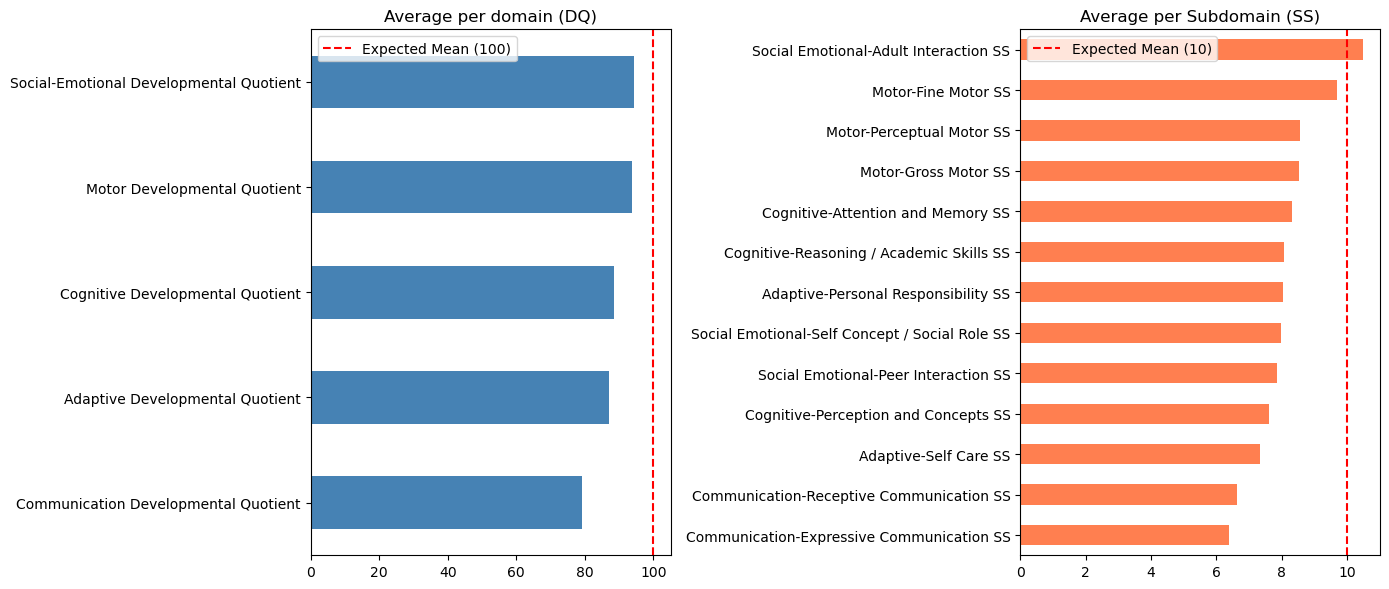

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

domain_serie.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Average per domain (DQ)')
axes[0].axvline(100, color='red', linestyle='--', label='Expected Mean (100)')
axes[0].legend()

subdomain_series.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Average per Subdomain (SS)')
axes[1].axvline(10, color='red', linestyle='--', label='Expected Mean (10)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. What is the pattern of children's scores? Do individual children tend to perform similarly across all domains or are there differences from domain to domain? Are these patterns similar for all children?

In [25]:
domain_columns = []
for col in df.columns:
    if 'Developmental Quotient' in col and 'Total' not in col:
        domain_columns.append(col)
domain_columns

['Adaptive Developmental Quotient',
 'Social-Emotional Developmental Quotient',
 'Communication Developmental Quotient',
 'Motor Developmental Quotient',
 'Cognitive Developmental Quotient']

In [26]:
correlation = df[domain_columns].corr()
print(correlation.round(2))

                                         Adaptive Developmental Quotient  \
Adaptive Developmental Quotient                                     1.00   
Social-Emotional Developmental Quotient                             0.62   
Communication Developmental Quotient                                0.56   
Motor Developmental Quotient                                        0.60   
Cognitive Developmental Quotient                                    0.55   

                                         Social-Emotional Developmental Quotient  \
Adaptive Developmental Quotient                                             0.62   
Social-Emotional Developmental Quotient                                     1.00   
Communication Developmental Quotient                                        0.64   
Motor Developmental Quotient                                                0.54   
Cognitive Developmental Quotient                                            0.66   

                                      

In [27]:
df = df.copy()
df['range_between_domains'] = df[domain_columns].max(axis=1) - df[domain_columns].min(axis=1)
print(df['range_between_domains'])

0        42.0
1        16.0
2        27.0
3        27.0
4        27.0
5        12.0
6        40.0
7        27.0
8        37.0
9        12.0
10       48.0
11       39.0
12       22.0
13       20.0
14       42.0
15       32.0
16       42.0
17       33.0
18       45.0
19        8.0
20        8.0
21       22.0
22       22.0
23       35.0
24       42.0
25       42.0
26       21.0
27       12.0
28       12.0
29       34.0
30       34.0
31       31.0
32       31.0
33       22.0
34       20.0
35       20.0
36       21.0
37       23.0
38       22.0
39       36.0
40       36.0
41       22.0
42       22.0
43       13.0
44       13.0
45       15.0
46       15.0
47       37.0
48       37.0
49       12.0
50       38.0
51       15.0
52       27.0
53       16.0
54       16.0
55       19.0
56       19.0
57       22.0
58       22.0
59       22.0
60       33.0
61       44.0
62       44.0
63       30.0
64       30.0
65       11.0
66       11.0
67       30.0
68       30.0
69        6.0
70        6.0
71    

In [28]:
less_than_10_points = (df['range_between_domains'] < 10).sum()
less_than_10_points

np.int64(575)

In [29]:
more_than_30_points = (df['range_between_domains'] > 30).sum()
more_than_30_points

np.int64(10564)

In [30]:
points_range = (df['range_between_domains'].max() - df['range_between_domains'].min())
points_range

np.float64(87.0)

In [31]:
# verification
print("How many columns were found?:", len(domain_columns))
print(domain_columns)

How many columns were found?: 5
['Adaptive Developmental Quotient', 'Social-Emotional Developmental Quotient', 'Communication Developmental Quotient', 'Motor Developmental Quotient', 'Cognitive Developmental Quotient']


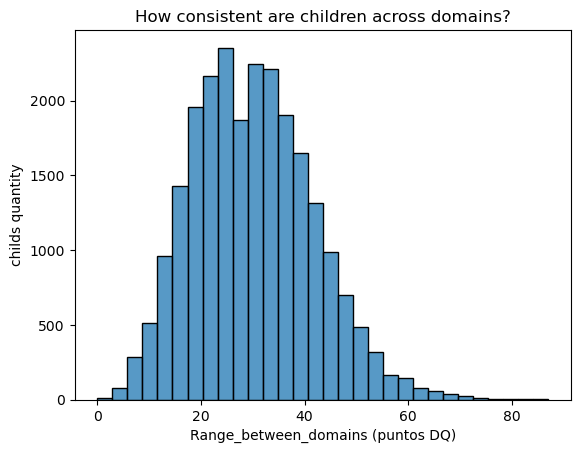

In [32]:
sns.histplot(df['range_between_domains'], bins=30)
plt.xlabel('Range_between_domains (puntos DQ)')
plt.ylabel('childs quantity')
plt.title('How consistent are children across domains?')
plt.show()

### a. The domains are moderately correlated (between 0.54 and 0.73)—neither low enough to be independent nor high enough (such as 0.9+) to be "practically the same score." The strongest correlation is Communication↔Cognitive (0.73), and the weakest is Adaptive↔Cognitive (0.55).

### b. On average, the range between each child's highest and lowest domain is 29.9 points (median: 29). Given that 1 standard deviation equals 15 points, a range of ~30 points means that most children show a difference of at least two standard deviations between their best and worst domains. Conclusion: they are inconsistent—there are real differences across domains for the majority.

### c. The typical pattern is that children do show significant differences across domains (not a flat profile), but the magnitude of that difference varies greatly from child to child—there is no single "universal pattern."

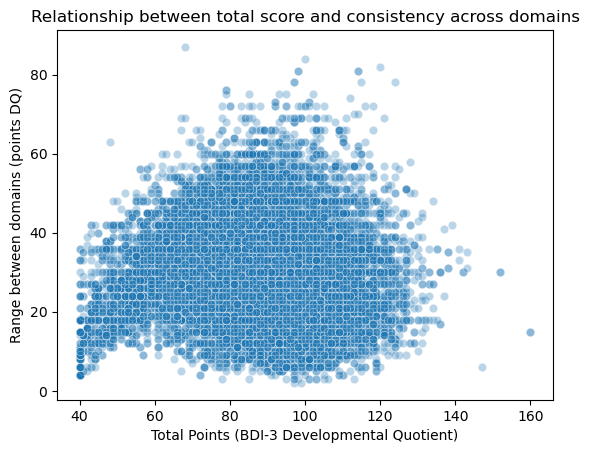

In [33]:
sns.scatterplot(x='BDI-3 Total Developmental Quotient', y='range_between_domains', data=df, alpha=0.3)
plt.xlabel('Total Points (BDI-3 Developmental Quotient)')
plt.ylabel('Range between domains (points DQ)')
plt.title('Relationship between total score and consistency across domains')
plt.show()

In [34]:
# sns.scatterplot(x='Chronological Age', y='range_between_domains', data=df, alpha=0.3)

## 3. Is there a pattern of significant differences in children's scores in the sub-domains within a domain?​

In [35]:
subdomains_per_domain = {}

for col in df.columns:
    if col.endswith(' SS'):
        domain_name = col.split('-')[0]
        domain_name = domain_name.replace(' ', '-')
        
        if domain_name not in subdomains_per_domain:
            subdomains_per_domain[domain_name] = []
        
        subdomains_per_domain[domain_name].append(col)

subdomains_per_domain

{'Adaptive': ['Adaptive-Self Care SS', 'Adaptive-Personal Responsibility SS'],
 'Social-Emotional': ['Social Emotional-Adult Interaction SS',
  'Social Emotional-Peer Interaction SS',
  'Social Emotional-Self Concept / Social Role SS'],
 'Communication': ['Communication-Receptive Communication SS',
  'Communication-Expressive Communication SS'],
 'Motor': ['Motor-Gross Motor SS',
  'Motor-Fine Motor SS',
  'Motor-Perceptual Motor SS'],
 'Cognitive': ['Cognitive-Attention and Memory SS',
  'Cognitive-Reasoning / Academic Skills SS',
  'Cognitive-Perception and Concepts SS']}

In [36]:
for domain in subdomains_per_domain:
    subdomains = subdomains_per_domain[domain]
    
    for col in subdomains:
        print('  mean of', col, ':', round(df[col].mean(), 2))
#        print('  standard deviation of', col, ':', round(df[col].std(), 2))
    
    for i in range(len(subdomains)):
        for j in range(i + 1, len(subdomains)):
            column_1 = subdomains[i]
            column_2 = subdomains[j]
            
            data_pair = df[[column_1, column_2]].dropna()
            
            result = stats.ttest_rel(data_pair[column_1], data_pair[column_2])
            diference = data_pair[column_1] - data_pair[column_2]
            cohen_d = diference.mean() / diference.std()
            print('  ', column_1, 'vs', column_2, '-> p-value:', round(result.pvalue, 5))
            print('  ', column_1, 'vs', column_2, "-> Cohen's d:", round(cohen_d, 2))
#    print()

  mean of Adaptive-Self Care SS : 7.32
  mean of Adaptive-Personal Responsibility SS : 8.02
   Adaptive-Self Care SS vs Adaptive-Personal Responsibility SS -> p-value: 0.0
   Adaptive-Self Care SS vs Adaptive-Personal Responsibility SS -> Cohen's d: -0.4
  mean of Social Emotional-Adult Interaction SS : 10.48
  mean of Social Emotional-Peer Interaction SS : 7.86
  mean of Social Emotional-Self Concept / Social Role SS : 7.99
   Social Emotional-Adult Interaction SS vs Social Emotional-Peer Interaction SS -> p-value: 0.0
   Social Emotional-Adult Interaction SS vs Social Emotional-Peer Interaction SS -> Cohen's d: 1.01
   Social Emotional-Adult Interaction SS vs Social Emotional-Self Concept / Social Role SS -> p-value: 0.0
   Social Emotional-Adult Interaction SS vs Social Emotional-Self Concept / Social Role SS -> Cohen's d: 0.92
   Social Emotional-Peer Interaction SS vs Social Emotional-Self Concept / Social Role SS -> p-value: 0.0
   Social Emotional-Peer Interaction SS vs Social E

## 5. Eligibility is currently based on domains. A child would be considered eligible based on a 40% delay in one area or 25% delay in two areas, as determined by Development Quotient (DQ) scores. A DQ of 70 or less indicates a 40% delay, and a DQ between 71 and 78 indicates a 25% delay. If TEIS added an option for eligibility based on the total score on the BDI-3 total score (DQ score of 70 or less), are there any children who would have qualified that did not qualify based on the current method?

In [37]:
domain_columns = []
for col in df.columns:
    if 'Developmental Quotient' in col and 'Total' not in col:
        domain_columns.append(col)

total_column = 'BDI-3 Total Developmental Quotient'

# any domain with DQ <= 70 ( 40% behind)
condition_40 = (df[domain_columns] <= 70).any(axis=1)

# second current condition - at least 2 domains between 71 and 78 (25% behind)
in_range_25 = (df[domain_columns] >= 71) & (df[domain_columns] <= 78)
count_in__25 = in_range_25.sum(axis=1)
condition_25 = count_in__25 >= 2

# eligibility by current conditions
eligible_actual = condition_40 | condition_25

# eligibility by the new proposed rule
eligible_new = df[total_column] <= 70

# amount of new children by the new rule
win_eligility = eligible_new & (~eligible_actual)

print('Children eligible under the current rule:', eligible_actual.sum())
print('Children eligible under the new rule:', eligible_new.sum())
print('Children who would gain eligibility with the change:', win_eligility.sum())

Children eligible under the current rule: 11650
Children eligible under the new rule: 3962
Children who would gain eligibility with the change: 0


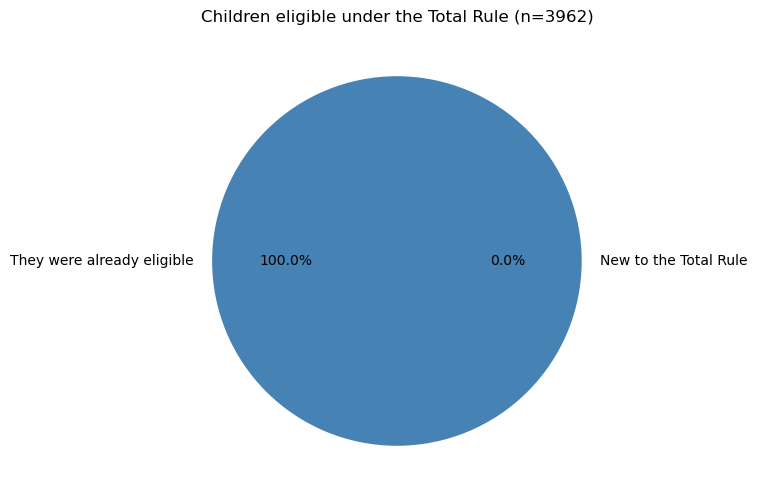

In [38]:
eligibles_now = (eligible_new & eligible_actual).sum()
news_total = win_eligility.sum()

plt.figure(figsize=(6, 6))
plt.pie([eligibles_now, news_total], 
        labels=['They were already eligible', 'New to the Total Rule'],
        autopct='%1.1f%%',
        colors=['steelblue', 'firebrick'])
plt.title('Children eligible under the Total Rule (n=' + str(eligible_new.sum()) + ')')
plt.show()

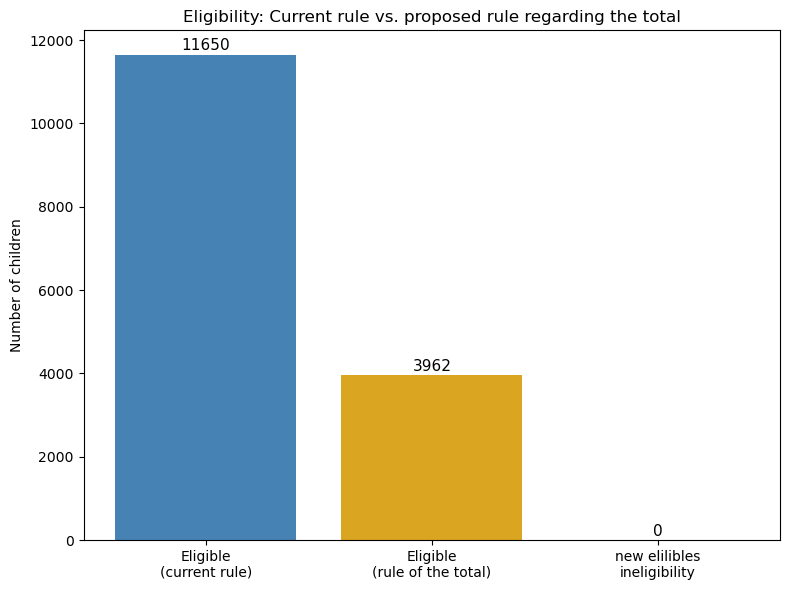

In [41]:
categories = ['Eligible\n(current rule)', 'Eligible\n(rule of the total)', 'new elilibles\nineligibility']
values = [eligible_actual.sum(), eligible_new.sum(), win_eligility.sum()]
colors = ['steelblue', 'goldenrod', 'firebrick']

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, values, color=colors)

for bar in bars:
    high = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, high + 100, str(high),
              ha='center', fontsize=11)

plt.ylabel('Number of children')
plt.title('Eligibility: Current rule vs. proposed rule regarding the total')
plt.tight_layout()
plt.show()